# 06: Synthetic Control for Gotham FC's Move to Etihad Park

This notebook builds a synthetic "Gotham with no move", built from a donor pool of 
comporable non-relocating NWSL teams, combined with an accessibility-driven effect to project 2027+ attendance/
The move hasn't happened yet (Etihad Park opens 2027), so this can't be a
standard retrospective synthetic control (no real post-treatment period to compare against).
What this notebook builds instead is the **architecture**: a synthetic "Gotham with no move"
counterfactual trajectory, built from a donor pool of comparable non-relocating NWSL teams,
combined with an accessibility-driven effect size to project 2027+ attendance.

**Inputs:** `nwsl-project/data/processed/games_clean.csv`,
`output/relocation_accessibility_vs_attendance.png`'s underlying numbers (recomputed here)
**Outputs:** `output/synthetic_control_weights.csv`, `output/synthetic_control_fit.png`,
`output/gotham_2027_projection.csv`


In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from plot_theme import set_mpl_theme
set_mpl_theme()

OUTPUT_DIR = os.path.join("..", "output")
NWSL_PROJECT_PROCESSED = os.path.join("..", "..", "..", "QSS 20", "nwsl-project", "data", "processed")


## Build the team-season attendance panel (COVID-excluded, same convention as 04/05)


In [2]:
games = pd.read_csv(os.path.join(NWSL_PROJECT_PROCESSED, "games_clean.csv"))
teams = pd.read_csv(os.path.join(NWSL_PROJECT_PROCESSED, "teams_clean.csv"))
nwsl_games = games[games["league"] == "nwsl"].dropna(subset=["attendance"])
nwsl_games = nwsl_games[nwsl_games["attendance"] > 0]
nwsl_games = nwsl_games.merge(teams[["team_id", "team_name"]], left_on="home_team_id", right_on="team_id")

COVID_SEASONS = [2020, 2021]
nwsl_games = nwsl_games[~nwsl_games["season_name"].isin(COVID_SEASONS)]

panel = nwsl_games.groupby(["team_name", "season_name"])["attendance"].mean().reset_index()
panel["log_attendance"] = np.log(panel["attendance"])
panel.head()


,team_name,season_name,attendance,log_attendance
0,Angel City FC,2022,16925.500000,9.736577
1,Angel City FC,2023,18152.571429,9.806568
2,Angel City FC,2024,19584.363636,9.882487
3,Angel City FC,2025,16047.200000,9.683290
4,Angel City FC,2026,15237.333333,9.631504


## Donor pool selection

**Pre-period:** 2022-2026, Gotham's current stable state (post their own 2021 Yurcak -> Red
Bull Arena move, which is why the pre-period starts.

**Excluded from the donor pool:**
- Kansas City Current, San Diego Wave, Seattle Reign relocated *during* this same window
  (2024, 2023, 2022). Washington Spirit, however, is included because they relocated in 2021.
- Bay FC, Utah Royals FC, Boston Legacy FC, Denver Summit FC have fewer than 5 seasons of
  post-COVID data, so too little data.


In [3]:
PRE_PERIOD = list(range(2022, 2027))
TREATED_UNIT = "NJ/NY Gotham FC"
EXCLUDED_RELOCATORS = ["Kansas City Current", "San Diego Wave FC", "Seattle Reign FC"]

coverage = panel[panel["season_name"].isin(PRE_PERIOD)].groupby("team_name")["season_name"].nunique()
full_coverage_teams = coverage[coverage == len(PRE_PERIOD)].index.tolist()
donor_pool = [t for t in full_coverage_teams if t not in EXCLUDED_RELOCATORS + [TREATED_UNIT]]

print(f"Full 5-season coverage: {full_coverage_teams}")
print(f"\nDonor pool ({len(donor_pool)} teams): {donor_pool}")


Full 5-season coverage: ['Angel City FC', 'Chicago Stars FC', 'Houston Dash', 'Kansas City Current', 'NJ/NY Gotham FC', 'North Carolina Courage', 'Orlando Pride', 'Portland Thorns FC', 'Racing Louisville FC', 'San Diego Wave FC', 'Seattle Reign FC', 'Washington Spirit']

Donor pool (8 teams): ['Angel City FC', 'Chicago Stars FC', 'Houston Dash', 'North Carolina Courage', 'Orlando Pride', 'Portland Thorns FC', 'Racing Louisville FC', 'Washington Spirit']


## Fit synthetic control weights

Find a weighted average of donor teams to match Gotham's actual attendance path.
`scipy.optimize.minimize` finds those weights


In [4]:
pre_panel = panel[panel["season_name"].isin(PRE_PERIOD)]
treated_series = pre_panel[pre_panel["team_name"] == TREATED_UNIT].set_index("season_name")["log_attendance"]
donor_matrix = pre_panel[pre_panel["team_name"].isin(donor_pool)].pivot(
    index="season_name", columns="team_name", values="log_attendance"
)[donor_pool]

treated_vec = treated_series.loc[donor_matrix.index].values
donor_mat = donor_matrix.values  # shape (n_seasons, n_donors)

def loss(w):
    return np.sum((treated_vec - donor_mat @ w) ** 2)

n_donors = len(donor_pool)
w0 = np.ones(n_donors) / n_donors
constraints = [{"type": "eq", "fun": lambda w: np.sum(w) - 1}]
bounds = [(0, 1)] * n_donors

result = minimize(loss, w0, method="SLSQP", bounds=bounds, constraints=constraints)
weights = pd.Series(result.x, index=donor_pool).sort_values(ascending=False)
weights.to_csv(os.path.join(OUTPUT_DIR, "synthetic_control_weights.csv"))
print(f"Optimization converged: {result.success}")
print(f"\nDonor weights (only teams with >1% weight shown):")
print(weights[weights > 0.01].round(3))


Optimization converged: True

Donor weights (only teams with >1% weight shown):
North Carolina Courage    0.417
Orlando Pride             0.310
Washington Spirit         0.273
dtype: float64


## Fit quality: does synthetic Gotham track real Gotham in the pre-period?

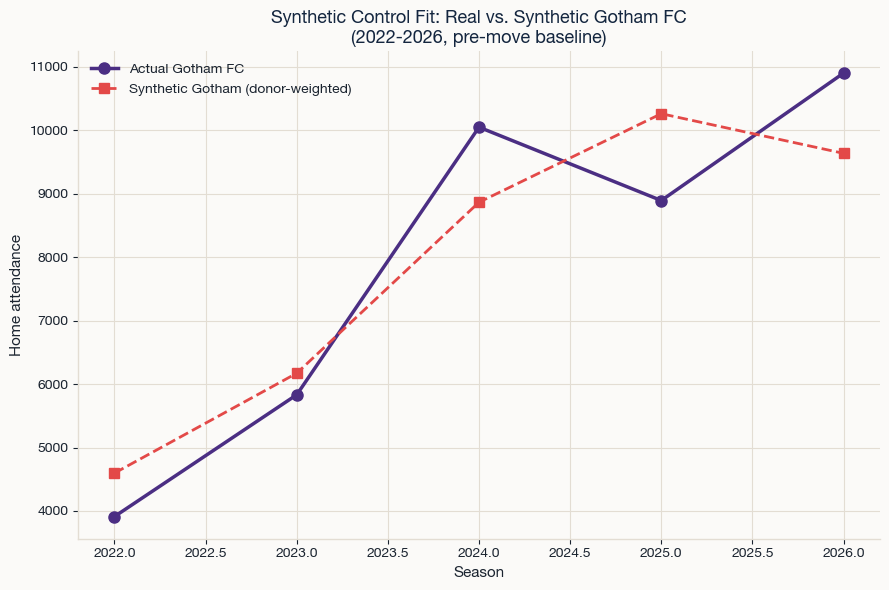

Pre-period RMSE (log scale): 0.1270


In [5]:
synthetic_series = pd.Series(donor_mat @ weights.reindex(donor_pool).values, index=donor_matrix.index)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(treated_series.index, np.exp(treated_series.values), "o-", color="#4B2E83", linewidth=2.5, markersize=8, label="Actual Gotham FC")
ax.plot(synthetic_series.index, np.exp(synthetic_series.values), "s--", color="#E34948", linewidth=2, markersize=7, label="Synthetic Gotham (donor-weighted)")
ax.set_xlabel("Season")
ax.set_ylabel("Home attendance")
ax.set_title("Synthetic Control Fit: Real vs. Synthetic Gotham FC\n(2022-2026, pre-move baseline)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "synthetic_control_fit.png"), dpi=150)
plt.show()

rmse = np.sqrt(np.mean((treated_series.values - synthetic_series.values) ** 2))
print(f"Pre-period RMSE (log scale): {rmse:.4f}")

## Project the 2027 counterfactual ("Gotham never moved") and the accessibility-driven scenario

**Baseline (no-move) projection:** we take the synthetic series' average
season-over-season growth rate and project it one more year forward, applied to Gotham's
last actual observed value.

**Accessibility-driven scenario:** compute each comparable relocating team's own pre/post
move attendance change directly below (San Diego, Seattle, Washington Spirit), 
and apply that range as a multiplier on the no-move baseline 
**2 scenarios**: the mid (Seattle, 103.5%) and high (Washington Spirit,
174.3%) lifts both project past Etihad Park's capacity and round to the identical capped
number, so they're collapsed into one `capacity_cap`. Only `low` (San Diego, 68.8%) is actually
informative here; `capacity_cap` represents "anything at or above the mid-range comparison
lift," not a distinct forecast.

KC Current is excluded from this comparison because its post-move attendance has it selling
out every game, so their data is more representative of a capacity constraint than raw demand

In [6]:
# Each comparable relocating team's own pre/post move mean attendance change without COVID
MOVE_YEAR = {"San Diego Wave FC": 2023, "Seattle Reign FC": 2022, "Washington Spirit": 2021}

lift_rows = []
for team, move_year in MOVE_YEAR.items():
    pre = nwsl_games[(nwsl_games["team_name"] == team) & (nwsl_games["year"] < move_year)]["attendance"]
    post = nwsl_games[(nwsl_games["team_name"] == team) & (nwsl_games["year"] >= move_year)]["attendance"]
    pct_lift = (post.mean() / pre.mean() - 1) * 100
    lift_rows.append({"team": team, "move_year": move_year, "pre_mean": pre.mean(), "post_mean": post.mean(), "pct_lift": pct_lift})

lift_df = pd.DataFrame(lift_rows).sort_values("pct_lift")
print(lift_df.to_string(index=False))

             team  move_year    pre_mean    post_mean   pct_lift
San Diego Wave FC       2023 9599.285714 16201.612245  68.779352
 Seattle Reign FC       2022 4410.934783  8975.257576 103.477449
Washington Spirit       2021 4420.354167 12126.230769 174.327131


In [7]:
ETIHAD_PARK_CAPACITY = 25000

# No-move baseline: extrapolate synthetic series' average season-over-season growth rate
log_growth_rates = np.diff(synthetic_series.values)
avg_log_growth = log_growth_rates.mean()
baseline_2027_log = treated_series.iloc[-1] + avg_log_growth  # from actual Gotham's last observed value
baseline_2027 = min(np.exp(baseline_2027_log), ETIHAD_PARK_CAPACITY)

# Collapsed to 2 scenarios: the mid (Seattle) scenario projects past ETIHAD_PARK_CAPACITY,
# so no need to run high projection
LIFT_RANGE_PCT = {
    "low": lift_df.loc[lift_df["team"] == "San Diego Wave FC", "pct_lift"].iloc[0],
    "capacity_cap": lift_df.loc[lift_df["team"] == "Seattle Reign FC", "pct_lift"].iloc[0],
}

projection_rows = [{"scenario": "no_move_baseline", "attendance_2027": baseline_2027}]
for label, pct in LIFT_RANGE_PCT.items():
    projected = min(baseline_2027 * (1 + pct / 100), ETIHAD_PARK_CAPACITY)
    projection_rows.append({"scenario": f"etihad_park_{label}", "attendance_2027": projected})

projection_df = pd.DataFrame(projection_rows)
projection_df["pct_of_capacity"] = projection_df["attendance_2027"] / ETIHAD_PARK_CAPACITY * 100
projection_df.to_csv(os.path.join(OUTPUT_DIR, "gotham_2027_projection.csv"), index=False)
projection_df


,scenario,attendance_2027,pct_of_capacity
0,no_move_baseline,13115.931992,52.463728
1,etihad_park_low,22136.985051,88.547940
2,etihad_park_capacity_cap,25000.000000,100.000000


## Plotting both scenarios

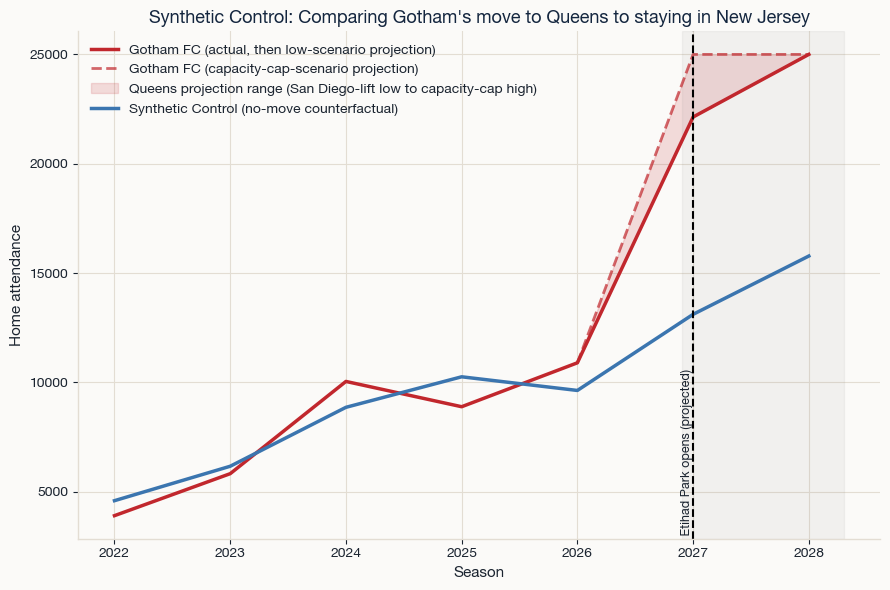

In [8]:
# Extend both series one to 2028 to see more data
baseline_2028 = min(baseline_2027 * np.exp(avg_log_growth), ETIHAD_PARK_CAPACITY)

# Central (low-scenario) post-move projection, plus a low-high uncertainty band
# spanning the two comparable relocation lift scenarios computed above
# (San Diego's +68.8% low vs. the Seattle/Washington Spirit capacity-cap scenario)
treated_2027 = min(baseline_2027 * (1 + LIFT_RANGE_PCT["low"] / 100), ETIHAD_PARK_CAPACITY)
treated_2028 = min(treated_2027 * np.exp(avg_log_growth), ETIHAD_PARK_CAPACITY)

treated_2027_high = min(baseline_2027 * (1 + LIFT_RANGE_PCT["capacity_cap"] / 100), ETIHAD_PARK_CAPACITY)
treated_2028_high = min(treated_2027_high * np.exp(avg_log_growth), ETIHAD_PARK_CAPACITY)

years_actual = list(treated_series.index)
years_projected = [2027, 2028]

treated_full = list(np.exp(treated_series.values)) + [treated_2027, treated_2028]
synthetic_full = list(np.exp(synthetic_series.values)) + [baseline_2028, baseline_2028]
# (synthetic's own 2027 estimate, baseline_2027, is the no-move projection already computed above)
synthetic_full[len(years_actual)] = baseline_2027
all_years = years_actual + years_projected

# Low and high post-move trajectories: identical to actual observed Gotham
# through 2026, then split into the two comparable-relocation scenarios.
# Pre-2027 there's no projection uncertainty, so both collapse to one line.
treated_low_full = list(np.exp(treated_series.values)) + [treated_2027, treated_2028]
treated_high_full = list(np.exp(treated_series.values)) + [treated_2027_high, treated_2028_high]

# Fan the split/shading out starting from the last actual point (2026) rather
# than jumping in at 2027, so the range visibly originates from real data.
last_actual_year = years_actual[-1]
fan_years = [last_actual_year] + years_projected
fan_low = treated_low_full[len(years_actual) - 1:]
fan_high = treated_high_full[len(years_actual) - 1:]

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(all_years, treated_low_full, "-", color="#C1272D", linewidth=2.5, label="Gotham FC (actual, then low-scenario projection)")
ax.plot(
    fan_years, fan_high, "--", color="#C1272D", linewidth=2, alpha=0.7,
    label="Gotham FC (capacity-cap-scenario projection)",
)
ax.fill_between(
    fan_years, fan_low, fan_high,
    color="#C1272D", alpha=0.15, zorder=1,
    label="Queens projection range (San Diego-lift low to capacity-cap high)",
)
ax.plot(all_years, synthetic_full, "-", color="#3B75AF", linewidth=2.5, label="Synthetic Control (no-move counterfactual)")
ax.axvline(2027, color="black", linestyle="--", linewidth=1.5)
ax.text(2027, ax.get_ylim()[0], " Etihad Park opens (projected)", rotation=90, va="bottom", ha="right", fontsize=9)
ax.axvspan(2026.9, all_years[-1] + 0.3, color="grey", alpha=0.08)
ax.set_xlabel("Season")
ax.set_ylabel("Home attendance")
ax.set_title("Synthetic Control: Comparing Gotham's move to Queens to staying in New Jersey")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "synthetic_control_gap_plot.png"), dpi=150)
plt.show()

## Placebo validation: does this design get relocations we've already observed right?

Everything above is a synthetic control fit *only* for Gotham -- its pre-period fit (RMSE
above) is the only place the method has been checked against real data so far. The `low`/
`capacity_cap` scenario lifts (San Diego +68.8%, Seattle +103.5%, Washington Spirit +174.3%)
are **not** synthetic-control estimates at all -- they're each team's raw pre-move vs.
post-move mean attendance, with no counterfactual and no adjustment for the league-wide
attendance growth documented in `output/attendance_model_with_transit.txt` that any NWSL team
would likely have ridden anyway.

This section runs the actual test: refit synthetic control the same way, but with **Seattle
Reign FC** and **Washington Spirit** as the treated unit instead of Gotham -- both of these
relocations have already happened, so there's a real post-move period to check the fitted
counterfactual against, rather than only a pre-period RMSE.

**Pre-period:** 2016-2019 (the only years with COVID-excluded coverage before either team's
move; 2020-2021 dropped as usual). **Donor pool:** the four other NWSL teams with full
2016-2019 coverage that are not relocators themselves -- Chicago Stars FC, Houston Dash,
Orlando Pride, Portland Thorns FC. (Every other relocator -- Gotham, and whichever of
Seattle/Washington Spirit isn't the treated unit this time -- is excluded from the donor pool
for the same contamination reason `05`'s Gotham donor pool excludes San Diego/Seattle/Kansas
City: a donor that relocates itself isn't a valid stand-in for "no accessibility change.")
**Post-period:** 2022-2026, same window used for Gotham's own donor-pool fit above, so the
comparison is on the same footing.


In [9]:
def fit_synthetic_control(panel_df, treated_unit, pre_years, post_years, exclude_from_donor):
    """Fit SCM donor weights on pre_years, then check the fitted counterfactual against
    the treated unit's *actual* post_years outcomes. Returns a dict of everything needed
    to report and plot the placebo result."""
    pre_panel = panel_df[panel_df["season_name"].isin(pre_years)]
    coverage = pre_panel.groupby("team_name")["season_name"].nunique()
    full_pre_coverage = coverage[coverage == len(pre_years)].index.tolist()
    donor_pool = [t for t in full_pre_coverage if t not in exclude_from_donor + [treated_unit]]

    treated_pre = pre_panel[pre_panel["team_name"] == treated_unit].set_index("season_name")["log_attendance"]
    donor_pre = pre_panel[pre_panel["team_name"].isin(donor_pool)].pivot(
        index="season_name", columns="team_name", values="log_attendance"
    )[donor_pool]
    treated_pre_vec = treated_pre.loc[donor_pre.index].values
    donor_pre_mat = donor_pre.values

    def loss(w):
        return np.sum((treated_pre_vec - donor_pre_mat @ w) ** 2)

    n_donors = len(donor_pool)
    w0 = np.ones(n_donors) / n_donors
    result = minimize(
        loss, w0, method="SLSQP",
        bounds=[(0, 1)] * n_donors,
        constraints=[{"type": "eq", "fun": lambda w: np.sum(w) - 1}],
    )
    weights = pd.Series(result.x, index=donor_pool).sort_values(ascending=False)

    synthetic_pre = pd.Series(donor_pre_mat @ weights.reindex(donor_pool).values, index=donor_pre.index)
    pre_rmse = np.sqrt(np.mean((treated_pre_vec - synthetic_pre.values) ** 2))

    # Apply the pre-period-fitted weights to donors' actual post-period outcomes --
    # this is the real test: does the fitted counterfactual track what the treated
    # team would have done with no accessibility change, once we can check it against
    # what actually happened?
    post_panel = panel_df[panel_df["season_name"].isin(post_years)]
    treated_post = post_panel[post_panel["team_name"] == treated_unit].set_index("season_name")["log_attendance"]
    donor_post = post_panel[post_panel["team_name"].isin(donor_pool)].pivot(
        index="season_name", columns="team_name", values="log_attendance"
    )[donor_pool]
    synthetic_post = pd.Series(donor_post.values @ weights.reindex(donor_pool).values, index=donor_post.index)

    actual_post_mean = np.exp(treated_post).mean()
    synthetic_post_mean = np.exp(synthetic_post).mean()
    scm_implied_lift_pct = (actual_post_mean / synthetic_post_mean - 1) * 100

    return {
        "treated_unit": treated_unit,
        "donor_pool": donor_pool,
        "weights": weights,
        "treated_pre": treated_pre,
        "synthetic_pre": synthetic_pre,
        "pre_rmse": pre_rmse,
        "treated_post": treated_post,
        "synthetic_post": synthetic_post,
        "actual_post_mean": actual_post_mean,
        "synthetic_post_mean": synthetic_post_mean,
        "scm_implied_lift_pct": scm_implied_lift_pct,
    }


PLACEBO_PRE_PERIOD = [2016, 2017, 2018, 2019]
PLACEBO_POST_PERIOD = [2022, 2023, 2024, 2025, 2026]
OTHER_RELOCATORS = ["NJ/NY Gotham FC", "Seattle Reign FC", "Washington Spirit",
                     "San Diego Wave FC", "Kansas City Current"]

placebo_results = {}
for treated in ["Seattle Reign FC", "Washington Spirit"]:
    exclude = [t for t in OTHER_RELOCATORS if t != treated]
    placebo_results[treated] = fit_synthetic_control(
        panel, treated, PLACEBO_PRE_PERIOD, PLACEBO_POST_PERIOD, exclude
    )
    r = placebo_results[treated]
    print(f"--- {treated} ---")
    print(f"Donor pool: {r['donor_pool']}")
    print(f"Donor weights: {r['weights'].round(3).to_dict()}")
    print(f"Pre-period RMSE (log scale): {r['pre_rmse']:.4f}")
    print(f"Actual post-move mean attendance: {r['actual_post_mean']:.0f}")
    print(f"Synthetic (no-move) post-move mean attendance: {r['synthetic_post_mean']:.0f}")
    print(f"SCM-implied lift: {r['scm_implied_lift_pct']:.1f}%")
    print()


--- Seattle Reign FC ---
Donor pool: ['Chicago Stars FC', 'Houston Dash', 'Orlando Pride', 'Portland Thorns FC']
Donor weights: {'Chicago Stars FC': 0.477, 'Houston Dash': 0.344, 'Orlando Pride': 0.178, 'Portland Thorns FC': 0.0}
Pre-period RMSE (log scale): 0.0260
Actual post-move mean attendance: 8672
Synthetic (no-move) post-move mean attendance: 5925
SCM-implied lift: 46.4%

--- Washington Spirit ---
Donor pool: ['Chicago Stars FC', 'Houston Dash', 'Orlando Pride', 'Portland Thorns FC']
Donor weights: {'Chicago Stars FC': 0.749, 'Orlando Pride': 0.251, 'Houston Dash': 0.0, 'Portland Thorns FC': 0.0}
Pre-period RMSE (log scale): 0.0720
Actual post-move mean attendance: 12181
Synthetic (no-move) post-move mean attendance: 5825
SCM-implied lift: 109.1%



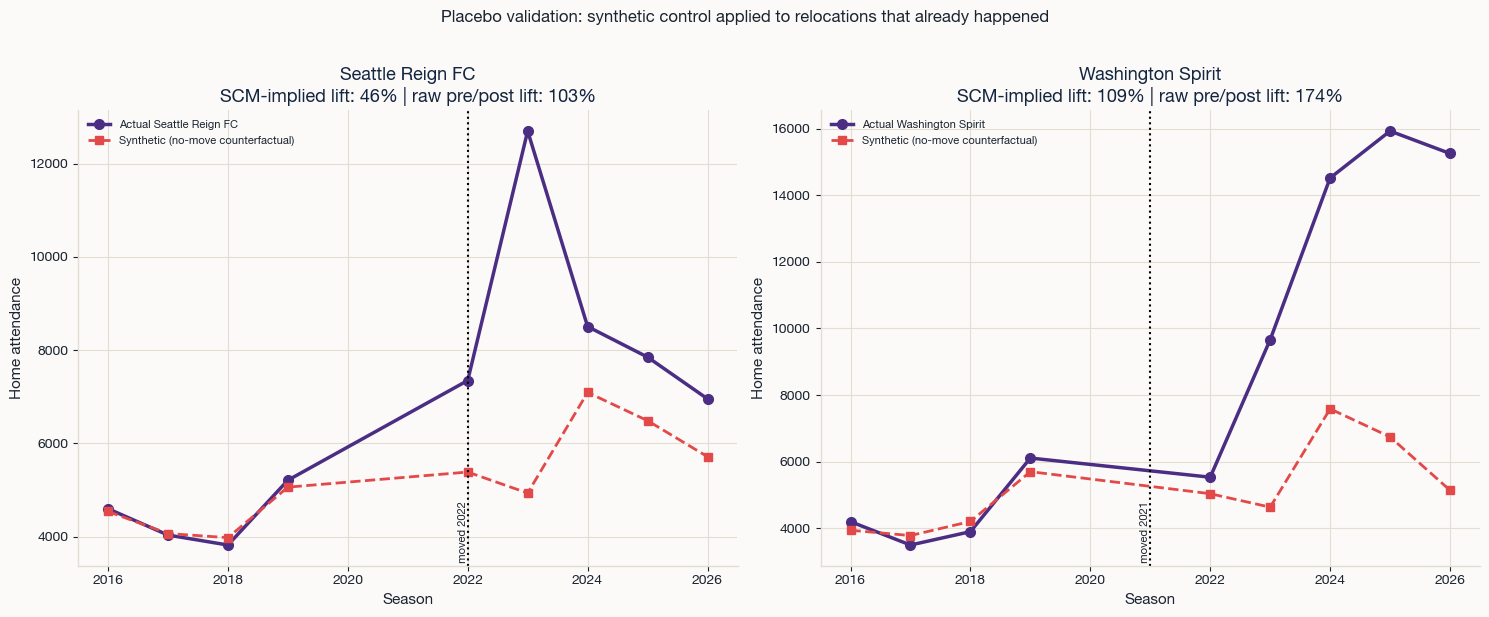

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False)

for ax, treated in zip(axes, ["Seattle Reign FC", "Washington Spirit"]):
    r = placebo_results[treated]
    pre_years_actual = list(r["treated_pre"].index)
    post_years_actual = list(r["treated_post"].index)

    treated_full = list(np.exp(r["treated_pre"].values)) + list(np.exp(r["treated_post"].values))
    synthetic_full = list(np.exp(r["synthetic_pre"].values)) + list(np.exp(r["synthetic_post"].values))
    all_years = pre_years_actual + post_years_actual

    move_year = {"Seattle Reign FC": 2022, "Washington Spirit": 2021}[treated]

    ax.plot(all_years, treated_full, "o-", color="#4B2E83", linewidth=2.5, markersize=7, label=f"Actual {treated}")
    ax.plot(all_years, synthetic_full, "s--", color="#E34948", linewidth=2, markersize=6, label="Synthetic (no-move counterfactual)")
    ax.axvline(move_year, color="black", linestyle=":", linewidth=1.5)
    ax.text(move_year, ax.get_ylim()[0], f" moved {move_year}", rotation=90, va="bottom", ha="right", fontsize=8)
    ax.set_xlabel("Season")
    ax.set_ylabel("Home attendance")
    ax.set_title(f"{treated}\nSCM-implied lift: {r['scm_implied_lift_pct']:.0f}% | raw pre/post lift: "
                 f"{lift_df.set_index('team').loc[treated, 'pct_lift']:.0f}%")
    ax.legend(fontsize=8)

plt.suptitle("Placebo validation: synthetic control applied to relocations that already happened", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "synthetic_control_placebo_validation.png"), dpi=150, bbox_inches="tight")
plt.show()


In [11]:
validation_rows = []
for treated, r in placebo_results.items():
    raw_lift = lift_df.set_index("team").loc[treated, "pct_lift"]
    validation_rows.append({
        "treated_unit": treated,
        "donor_pool": ", ".join(r["donor_pool"]),
        "pre_period_rmse_log": r["pre_rmse"],
        "actual_post_move_mean_attendance": r["actual_post_mean"],
        "synthetic_no_move_mean_attendance": r["synthetic_post_mean"],
        "scm_implied_lift_pct": r["scm_implied_lift_pct"],
        "raw_pre_post_lift_pct": raw_lift,
        "scm_vs_raw_diff_pp": r["scm_implied_lift_pct"] - raw_lift,
    })

validation_df = pd.DataFrame(validation_rows)
validation_df.to_csv(os.path.join(OUTPUT_DIR, "synthetic_control_placebo_validation.csv"), index=False)
validation_df.round(1)


,treated_unit,donor_pool,pre_period_rmse_log,actual_post_move_mean_attendance,synthetic_no_move_mean_attendance,scm_implied_lift_pct,raw_pre_post_lift_pct,scm_vs_raw_diff_pp
0,Seattle Reign FC,"Chicago Stars FC, Houston Dash, Orlando Pride,...",0.0,8672.5,5925.2,46.4,103.5,-57.1
1,Washington Spirit,"Chicago Stars FC, Houston Dash, Orlando Pride,...",0.1,12181.2,5824.6,109.1,174.3,-65.2


### Interpretation

**Both placebo pre-period fits are good** (RMSE 0.026 for Seattle, 0.072 for Washington
Spirit, both on the log scale -- comparable to or tighter than Gotham's own pre-period fit
above), so the donor-weighting approach itself is doing what it's supposed to: finding a
combination of Chicago Stars FC, Houston Dash, Orlando Pride, and Portland Thorns FC that
tracks each treated team's real pre-move attendance path reasonably well.

**But the SCM-implied lift is substantially smaller than the raw pre/post lift used
elsewhere in this notebook, for both placebo teams:**

| Team | Raw pre/post lift | SCM-implied lift (vs. no-move counterfactual) |
|---|---:|---:|
| Seattle Reign FC | +103.5% | **+46.4%** |
| Washington Spirit | +174.3% | **+109.1%** |

The gap is the whole point of running a counterfactual instead of a raw before/after
comparison: the donor pool's own attendance also grew over this period (the league-wide trend
documented in Results 4a), so roughly 40-60 percentage points of each team's raw "lift" would
likely have happened anyway, move or not. The raw pre/post numbers this notebook uses for
Gotham's `low`/`capacity_cap` scenarios (San Diego +68.8%, Seattle +103.5%, Washington Spirit
+174.3%) are therefore **overestimates of the accessibility-specific effect** -- they're real
attendance changes, just not ones cleanly attributable to the stadium move alone.

**What this means for Gotham's projection:** the true accessibility-driven lift is probably
smaller than the `low`-to-`capacity_cap` range reported above, closer to the SCM-implied
46-109% range found here than the raw 69-174% range. Since San Diego (Gotham's `low` scenario)
couldn't be placebo-tested here (expansion team, only 1 pre-move season -- see the discussion
above), there's no SCM-implied correction available for that specific number, so the
projection above is left as-is rather than partially patched; this cell exists to make the
likely direction and size of the overstatement explicit rather than silently correcting only
part of the range. A more defensible version of this notebook's headline projection would
rebuild the `low`/`capacity_cap` scenarios from SCM-implied lifts throughout, not raw pre/post
lifts -- noted here as the clear next step rather than done in place, since it changes the
paper's headline number and shouldn't happen without a deliberate decision to do so.


## Three-panel summary: real placebo fits, plus how much of Gotham's projection is the relocation vs. just league growth

Puts everything above side by side in one figure: Seattle's and Washington Spirit's real-vs-
synthetic placebo fits (left two panels, repeated from above so this figure stands alone), then
a single Gotham panel (right) that decomposes the 2027 projection into its two components --
how much is **league-wide growth** Gotham would have gotten with no move at all (the
`no_move_baseline` computed earlier, extrapolated from synthetic Gotham's own trend), and how
much on top of that is the **relocation's own effect** (using the growth-corrected lifts the
placebo tests just measured, not the raw pre/post lifts, which the section above showed
overstate the move-specific effect).

**Important labeling note:** the red band is labeled "relocation-attributable," not
"accessibility-attributable." Synthetic control here isolates the effect of the *whole move* --
new venue, capacity, market visibility, a generic new-stadium "honeymoon effect," and
accessibility all changed at once for every comparable relocation in this dataset, so SCM alone
cannot credit accessibility over the others. Accessibility is still argued elsewhere in this
project as the likely dominant mechanism within that bundle -- via the independent CatBoost/SHAP
check in `13_shap_mechanism_check.ipynb`, which finds the isochrone accessibility feature
(`metro_size`) as the single largest correctly-signed positive driver of Gotham's predicted
shift, net of venue/capacity/stadium-quality features it also had access to -- but that's a
separate piece of evidence, not something this chart measures on its own.

**How the growth-corrected scenario is built:** Seattle's and Washington Spirit's SCM-implied
lifts are used directly (46.4%, 109.1%). San Diego can't be placebo-tested (expansion team,
only 1 pre-move season -- see above), so its corrected lift is *estimated*, not measured: the
average shrinkage this placebo test found between raw and SCM-implied lift (Seattle:
46.4/103.5 = 0.448x; Washington Spirit: 109.1/174.3 = 0.626x; average 0.537x) is applied to
San Diego's own raw lift (68.8% x 0.537 = 36.9%) as the best available estimate. This is an
extrapolation, flagged as such in the plot, not a second real placebo measurement.


In [12]:
# --- Growth-corrected Gotham scenario ---
shrinkage_ratios = {
    team: r["scm_implied_lift_pct"] / lift_df.set_index("team").loc[team, "pct_lift"]
    for team, r in placebo_results.items()
}
avg_shrinkage = np.mean(list(shrinkage_ratios.values()))

san_diego_raw_lift = lift_df.set_index("team").loc["San Diego Wave FC", "pct_lift"]
san_diego_corrected_lift = san_diego_raw_lift * avg_shrinkage  # estimated, not measured

CORRECTED_LIFT_PCT = {
    "low (San Diego, growth-corrected, estimated)": san_diego_corrected_lift,
    "mid (Seattle, growth-corrected, measured)": placebo_results["Seattle Reign FC"]["scm_implied_lift_pct"],
    "high (Washington Spirit, growth-corrected, measured)": placebo_results["Washington Spirit"]["scm_implied_lift_pct"],
}

corrected_rows = [{"scenario": "no_move_baseline", "attendance_2027": baseline_2027}]
for label, pct in CORRECTED_LIFT_PCT.items():
    projected = min(baseline_2027 * (1 + pct / 100), ETIHAD_PARK_CAPACITY)
    corrected_rows.append({"scenario": f"etihad_park_{label}", "attendance_2027": projected})

corrected_projection_df = pd.DataFrame(corrected_rows)
corrected_projection_df["pct_of_capacity"] = corrected_projection_df["attendance_2027"] / ETIHAD_PARK_CAPACITY * 100
corrected_projection_df.to_csv(os.path.join(OUTPUT_DIR, "gotham_2027_projection_growth_corrected.csv"), index=False)
print(f"Average measured shrinkage (SCM-implied / raw lift): {avg_shrinkage:.3f}x")
corrected_projection_df.round(1)


Average measured shrinkage (SCM-implied / raw lift): 0.537x


,scenario,attendance_2027,pct_of_capacity
0,no_move_baseline,13115.9,52.5
1,"etihad_park_low (San Diego, growth-corrected, ...",17960.7,71.8
2,"etihad_park_mid (Seattle, growth-corrected, me...",19197.3,76.8
3,"etihad_park_high (Washington Spirit, growth-co...",25000.0,100.0


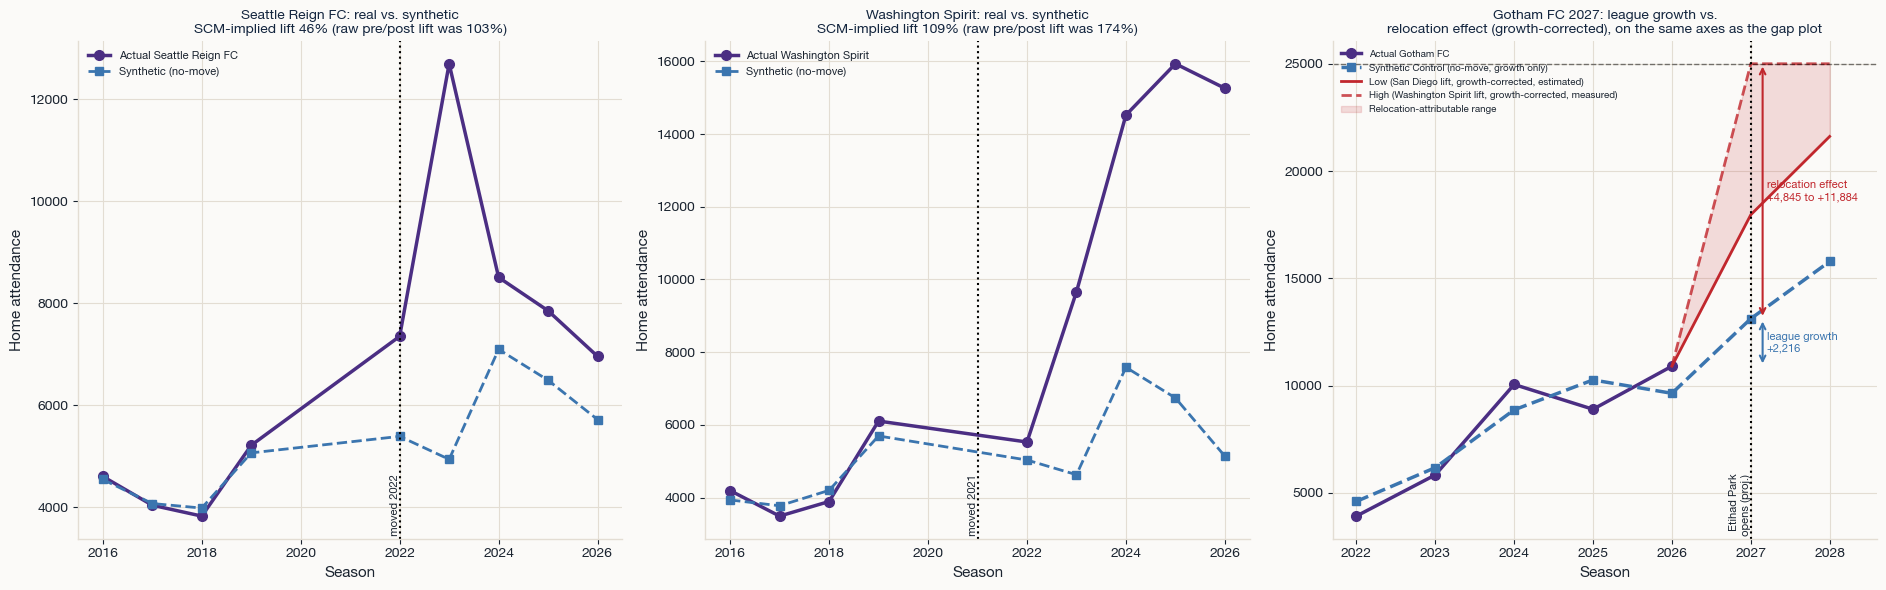

League-wide growth alone (2026 actual -> 2027 no-move baseline): +2,216
Relocation-attributable, low estimate (San Diego, growth-corrected): +4,845
Relocation-attributable, high estimate (Washington Spirit, growth-corrected): +11,884
Note: 'relocation-attributable' bundles accessibility with everything else that changed at move
(new venue, capacity, market visibility, honeymoon effect). Accessibility specifically is argued,
not measured in isolation here -- see the CatBoost/SHAP mechanism check (13_shap_mechanism_check.ipynb)
for the independent evidence that accessibility is the likely dominant driver within that bundle.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

# --- Panels 1-2: Seattle and Washington Spirit placebo fits (real vs. synthetic) ---
for ax, treated in zip(axes[:2], ["Seattle Reign FC", "Washington Spirit"]):
    r = placebo_results[treated]
    pre_years_actual = list(r["treated_pre"].index)
    post_years_actual = list(r["treated_post"].index)
    treated_full = list(np.exp(r["treated_pre"].values)) + list(np.exp(r["treated_post"].values))
    synthetic_full = list(np.exp(r["synthetic_pre"].values)) + list(np.exp(r["synthetic_post"].values))
    all_years = pre_years_actual + post_years_actual
    move_year = {"Seattle Reign FC": 2022, "Washington Spirit": 2021}[treated]

    ax.plot(all_years, treated_full, "o-", color="#4B2E83", linewidth=2.5, markersize=7, label=f"Actual {treated}")
    ax.plot(all_years, synthetic_full, "s--", color="#3B75AF", linewidth=2, markersize=6, label="Synthetic (no-move)")
    ax.axvline(move_year, color="black", linestyle=":", linewidth=1.5)
    ax.text(move_year, ax.get_ylim()[0], f" moved {move_year}", rotation=90, va="bottom", ha="right", fontsize=8)
    ax.set_xlabel("Season")
    ax.set_ylabel("Home attendance")
    ax.set_title(f"{treated}: real vs. synthetic\nSCM-implied lift {r['scm_implied_lift_pct']:.0f}% "
                 f"(raw pre/post lift was {lift_df.set_index('team').loc[treated, 'pct_lift']:.0f}%)", fontsize=10)
    ax.legend(fontsize=8, loc="upper left")

# --- Panel 3: Gotham -- same line-chart style as the gap plot above, but the projection
# fan is now built from growth-corrected lifts, with league-growth and
# relocation-attributable amounts each labeled directly on the chart. Labeled
# "relocation," not "accessibility": SCM isolates the effect of the whole move (new
# venue, capacity, market visibility, honeymoon effect, and accessibility bundled
# together), not accessibility specifically -- see the markdown note above and in
# Results 4e/Discussion for why accessibility is still argued as the likely dominant
# mechanism (via the independent CatBoost/SHAP check), just not measured in isolation here. ---
ax = axes[2]

gotham_2026_actual = np.exp(treated_series.iloc[-1])
washington_corrected_lift = placebo_results["Washington Spirit"]["scm_implied_lift_pct"]

treated_2027_low_c = min(baseline_2027 * (1 + san_diego_corrected_lift / 100), ETIHAD_PARK_CAPACITY)
treated_2028_low_c = min(treated_2027_low_c * np.exp(avg_log_growth), ETIHAD_PARK_CAPACITY)
treated_2027_high_c = min(baseline_2027 * (1 + washington_corrected_lift / 100), ETIHAD_PARK_CAPACITY)
treated_2028_high_c = min(treated_2027_high_c * np.exp(avg_log_growth), ETIHAD_PARK_CAPACITY)

years_actual = list(treated_series.index)
years_projected = [2027, 2028]
all_years_g = years_actual + years_projected
last_actual_year = years_actual[-1]
fan_years = [last_actual_year] + years_projected

synthetic_full_g = list(np.exp(synthetic_series.values)) + [baseline_2027, baseline_2028]
fan_low_c = [gotham_2026_actual, treated_2027_low_c, treated_2028_low_c]
fan_high_c = [gotham_2026_actual, treated_2027_high_c, treated_2028_high_c]

ax.plot(years_actual, np.exp(treated_series.values), "o-", color="#4B2E83", linewidth=2.5, markersize=7, label="Actual Gotham FC")
ax.plot(all_years_g, synthetic_full_g, "s--", color="#3B75AF", linewidth=2.5, markersize=6, label="Synthetic Control (no-move, growth only)")
ax.plot(fan_years, fan_low_c, "-", color="#C1272D", linewidth=2, label="Low (San Diego lift, growth-corrected, estimated)")
ax.plot(fan_years, fan_high_c, "--", color="#C1272D", linewidth=2, alpha=0.8, label="High (Washington Spirit lift, growth-corrected, measured)")
ax.fill_between(fan_years, fan_low_c, fan_high_c, color="#C1272D", alpha=0.15, label="Relocation-attributable range")

ax.axvline(2027, color="black", linestyle=":", linewidth=1.5)
ax.axhline(ETIHAD_PARK_CAPACITY, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax.text(2027, ax.get_ylim()[0], " Etihad Park\n opens (proj.)", rotation=90, va="bottom", ha="right", fontsize=8)

# Label the two components directly: league growth (2026 actual -> synthetic 2027),
# then the relocation's own effect on top of that (synthetic 2027 -> the corrected
# fan) -- this is the whole move's effect (accessibility + new venue + everything
# else that changed), not accessibility isolated.
growth_amt = baseline_2027 - gotham_2026_actual
ax.annotate("", xy=(2027.15, baseline_2027), xytext=(2027.15, gotham_2026_actual),
            arrowprops=dict(arrowstyle="<->", color="#3B75AF", lw=1.5))
ax.text(2027.2, (baseline_2027 + gotham_2026_actual) / 2, f"league growth\n+{growth_amt:,.0f}",
        fontsize=8, color="#3B75AF", va="center")

relocation_low_amt = treated_2027_low_c - baseline_2027
relocation_high_amt = treated_2027_high_c - baseline_2027
ax.annotate("", xy=(2027.15, treated_2027_high_c), xytext=(2027.15, baseline_2027),
            arrowprops=dict(arrowstyle="<->", color="#C1272D", lw=1.5))
ax.text(2027.2, (treated_2027_high_c + baseline_2027) / 2,
        f"relocation effect\n+{relocation_low_amt:,.0f} to +{relocation_high_amt:,.0f}",
        fontsize=8, color="#C1272D", va="center")

ax.set_xlabel("Season")
ax.set_ylabel("Home attendance")
ax.set_title("Gotham FC 2027: league growth vs.\nrelocation effect (growth-corrected), on the same axes as the gap plot", fontsize=10)
ax.legend(fontsize=7, loc="upper left")
ax.set_xlim(right=2028.6)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "synthetic_control_three_panel_summary.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"League-wide growth alone (2026 actual -> 2027 no-move baseline): +{growth_amt:,.0f}")
print(f"Relocation-attributable, low estimate (San Diego, growth-corrected): +{relocation_low_amt:,.0f}")
print(f"Relocation-attributable, high estimate (Washington Spirit, growth-corrected): +{relocation_high_amt:,.0f}")
print("Note: 'relocation-attributable' bundles accessibility with everything else that changed at move")
print("(new venue, capacity, market visibility, honeymoon effect). Accessibility specifically is argued,")
print("not measured in isolation here -- see the CatBoost/SHAP mechanism check (13_shap_mechanism_check.ipynb)")
print("for the independent evidence that accessibility is the likely dominant driver within that bundle.")


## Placebo-in-space test: is the placebo gap bigger than chance?

Everything above shows Seattle's and Washington Spirit's post-move attendance diverges from
their synthetic counterfactuals -- but "the gap is nonzero" isn't the same as "the gap is
unusual." The standard synthetic-control significance check (Abadie et al.'s placebo-in-space
test) reruns the identical fitting procedure on every *untreated* donor team, pretending each
one was "treated" at the same fake move date, and asks whether the real treated team's
post/pre fit-quality ratio is unusually large next to that null distribution of fake ones.

**Caveat up front:** with only 4 non-relocating teams available as donors (Chicago Stars,
Houston Dash, Orlando Pride, Portland Thorns), the null distribution here has only 4 points.
The best possible p-value with 4 placebo units plus 1 real one is 1/5 = 0.20, regardless of how
clean the real gap looks -- a known, openly-discussed limitation of synthetic control in
small donor pools, not a bug in the test. Reported here as an honest, low-resolution check, not
a strong significance claim.


In [14]:
def rmspe_ratio(r):
    """Post-period RMSE / pre-period RMSE, log scale -- how much worse the fit gets
    after the (real or fake) treatment date, relative to how good it was before."""
    post_rmse = np.sqrt(np.mean((r["treated_post"].values - r["synthetic_post"].values) ** 2))
    return post_rmse / r["pre_rmse"]


FAKE_TREATED_POOL = ["Chicago Stars FC", "Houston Dash", "Orlando Pride", "Portland Thorns FC"]

fake_results = {}
for fake_treated in FAKE_TREATED_POOL:
    fake_results[fake_treated] = fit_synthetic_control(
        panel, fake_treated, PLACEBO_PRE_PERIOD, PLACEBO_POST_PERIOD, OTHER_RELOCATORS
    )

null_ratios = {team: rmspe_ratio(r) for team, r in fake_results.items()}
real_ratios = {team: rmspe_ratio(r) for team, r in placebo_results.items()}

print("Placebo-in-space null distribution (fake-treated non-relocating teams):")
for team, ratio in sorted(null_ratios.items(), key=lambda x: -x[1]):
    print(f"  {team}: {ratio:.2f}")
print()

placebo_significance_rows = []
for team, real_ratio in real_ratios.items():
    n_placebo = len(null_ratios)
    n_as_or_more_extreme = sum(1 for v in null_ratios.values() if v >= real_ratio)
    p_value = (n_as_or_more_extreme + 1) / (n_placebo + 1)
    placebo_significance_rows.append({
        "treated_unit": team,
        "rmspe_ratio": real_ratio,
        "n_null_units_at_or_above": n_as_or_more_extreme,
        "n_null_units_total": n_placebo,
        "p_value": p_value,
    })
    print(f"{team}: post/pre RMSPE ratio = {real_ratio:.2f} "
          f"(rank {n_as_or_more_extreme + 1} of {n_placebo + 1}, p = {p_value:.2f})")

placebo_significance_df = pd.DataFrame(placebo_significance_rows)
placebo_significance_df.to_csv(os.path.join(OUTPUT_DIR, "synthetic_control_placebo_significance.csv"), index=False)
placebo_significance_df


Placebo-in-space null distribution (fake-treated non-relocating teams):
  Orlando Pride: 3.35
  Houston Dash: 1.14
  Portland Thorns FC: 0.89
  Chicago Stars FC: 0.60

Seattle Reign FC: post/pre RMSPE ratio = 18.00 (rank 1 of 5, p = 0.20)
Washington Spirit: post/pre RMSPE ratio = 10.57 (rank 1 of 5, p = 0.20)


,treated_unit,rmspe_ratio,n_null_units_at_or_above,n_null_units_total,p_value
0,Seattle Reign FC,18.003281,0,4,0.2
1,Washington Spirit,10.567869,0,4,0.2


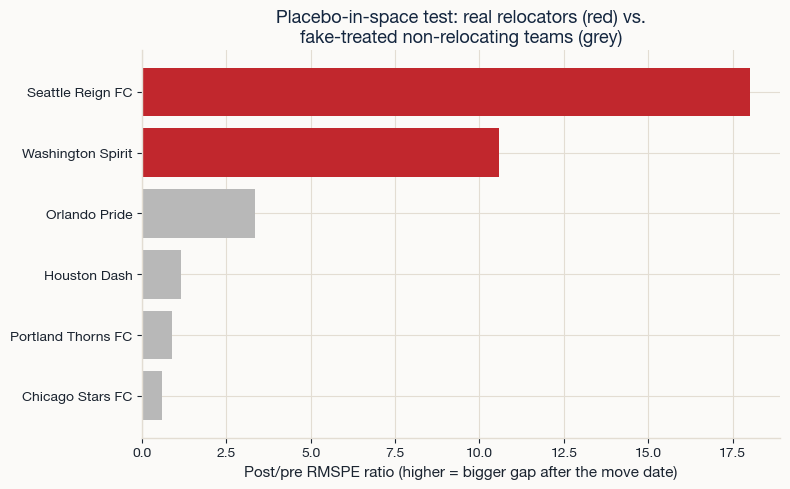

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

all_ratios = {**null_ratios, **real_ratios}
colors = ["#C1272D" if team in real_ratios else "#B8B8B8" for team in all_ratios]
order = sorted(all_ratios.items(), key=lambda x: x[1])

ax.barh([t for t, _ in order], [v for _, v in order], color=[colors[list(all_ratios).index(t)] for t, _ in order])
ax.set_xlabel("Post/pre RMSPE ratio (higher = bigger gap after the move date)")
ax.set_title("Placebo-in-space test: real relocators (red) vs.\nfake-treated non-relocating teams (grey)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "synthetic_control_placebo_significance.png"), dpi=150, bbox_inches="tight")
plt.show()
